In [1]:
import sys
sys.path.insert(0, '../lib')

import anndata as ad
import scanpy as sc
import random
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import common_data
import common_plots

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
common_plots.setup_plotting()

In [3]:
%config InlineBackend.figure_format = "retina"

In [4]:
adata = sc.read_h5ad(common_data.DATA / '08_geneformer/embeddings/embeddings.h5ad')

In [5]:
sorted(list(adata.obs.cell_type.unique()))

['AT1 and AT2',
 'B cells',
 'CD4 T cells',
 'CD8 T cells',
 'Ciliated cells',
 'Classical monocytes-1 CCR2',
 'Classical monocytes-2 IL1B',
 'DC1',
 'DC2',
 'Hematopoietic stem cells',
 'Interstitial macrophages',
 'Ionocytes',
 'MRC1+C1QA+',
 'MRC1+C1QA-',
 'Mast cells',
 'Migratory DC',
 'NUPR1+ Macs',
 'Non-classical monocytes',
 'Plasma cells',
 'Proliferating CD4 T cells',
 'Proliferating CD8 T cells',
 'Proliferating NUPR1+ Macs',
 'Proliferating gdT cells',
 'Proliferating plasma cells',
 'Secretory cells',
 'Tregs',
 'gdT cells',
 'pDC']

In [6]:
CELL_TYPE_ORDER = [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'DC2',
    'Classical monocytes-2 IL1B',
    'Classical monocytes-1 CCR2',
    'Non-classical monocytes',
    'Interstitial macrophages',
    'Proliferating NUPR1+ Macs',

    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'Tregs',
    'Proliferating CD4 T cells',
    'Proliferating CD8 T cells',

    'B cells',
    'Plasma cells',
    'Proliferating plasma cells',

    'Other'
]

In [7]:
len(CELL_TYPE_ORDER)

19

In [8]:
adata.obs['cell_type_display'] = adata.obs.cell_type.astype(str)
adata.obs.loc[~adata.obs.cell_type_display.isin(CELL_TYPE_ORDER), 'cell_type_display'] = 'Other'
adata.obs.cell_type_display = pd.Categorical(adata.obs.cell_type_display, categories=CELL_TYPE_ORDER)
adata.obs.cell_type_display = adata.obs.cell_type_display.cat.rename_categories(common_plots.CELL_TYPES_DISPLAY)
adata.obs['cell_type_num'] = pd.Categorical(adata.obs.cell_type_display.cat.codes + 1)

In [9]:
if 'cell_type_num_colors' in adata.uns:
    del adata.uns['cell_type_num_colors']

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

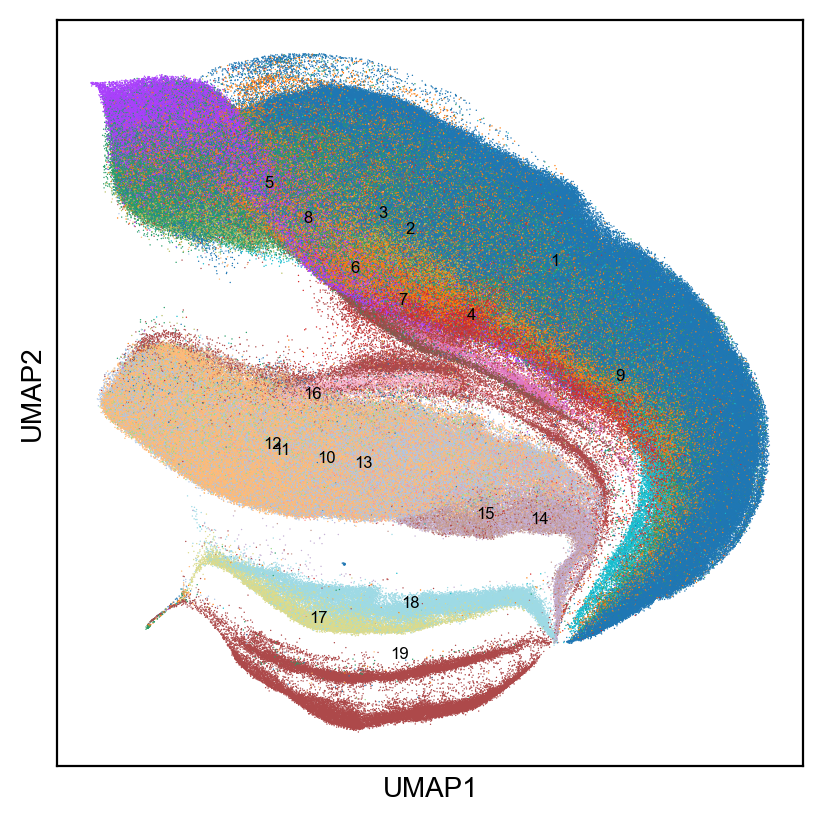

In [10]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
sc.pl.umap(
    adata,
    color='cell_type_num',
    legend_loc='on data',
    legend_fontweight='normal',
    legend_fontsize=6,
    title='',
    show=False,
    size=1,
    ax=ax
)

In [11]:
auto_colors = adata.uns['cell_type_num_colors'].copy()

In [12]:
rng = np.random.default_rng(seed=4738)
adata.uns['cell_type_num_colors'] = list(rng.permutation(auto_colors))
adata.uns['cell_type_num_colors'][-1] = '#999999'

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

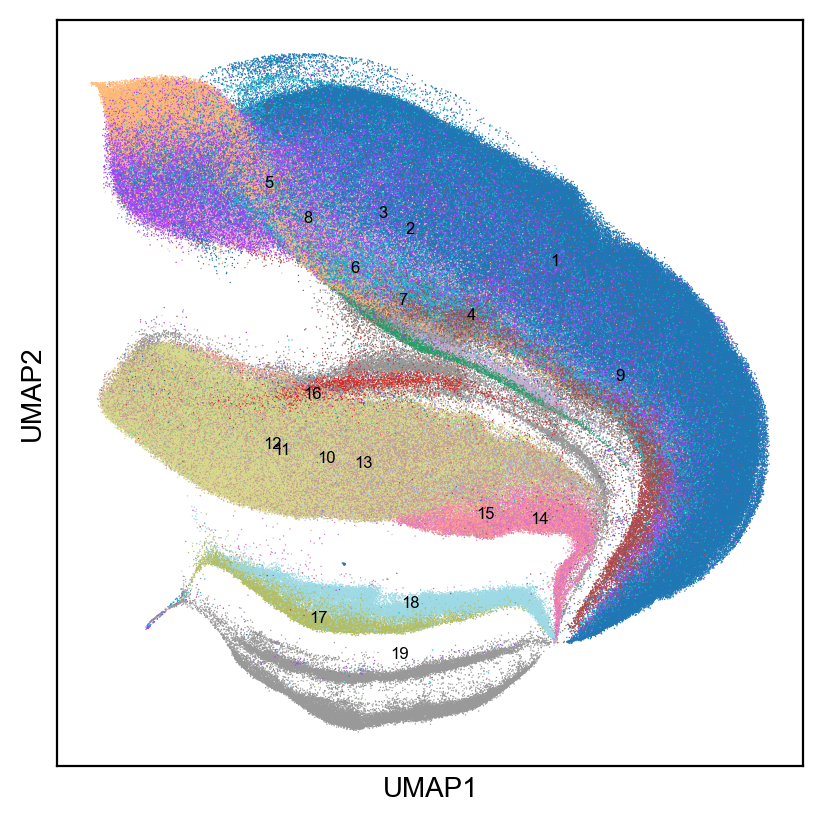

In [13]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
sc.pl.umap(
    adata,
    color='cell_type_num',
    legend_loc='on data',
    legend_fontweight='normal',
    legend_fontsize=6,
    title='',
    show=False,
    size=1,
    ax=ax
)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


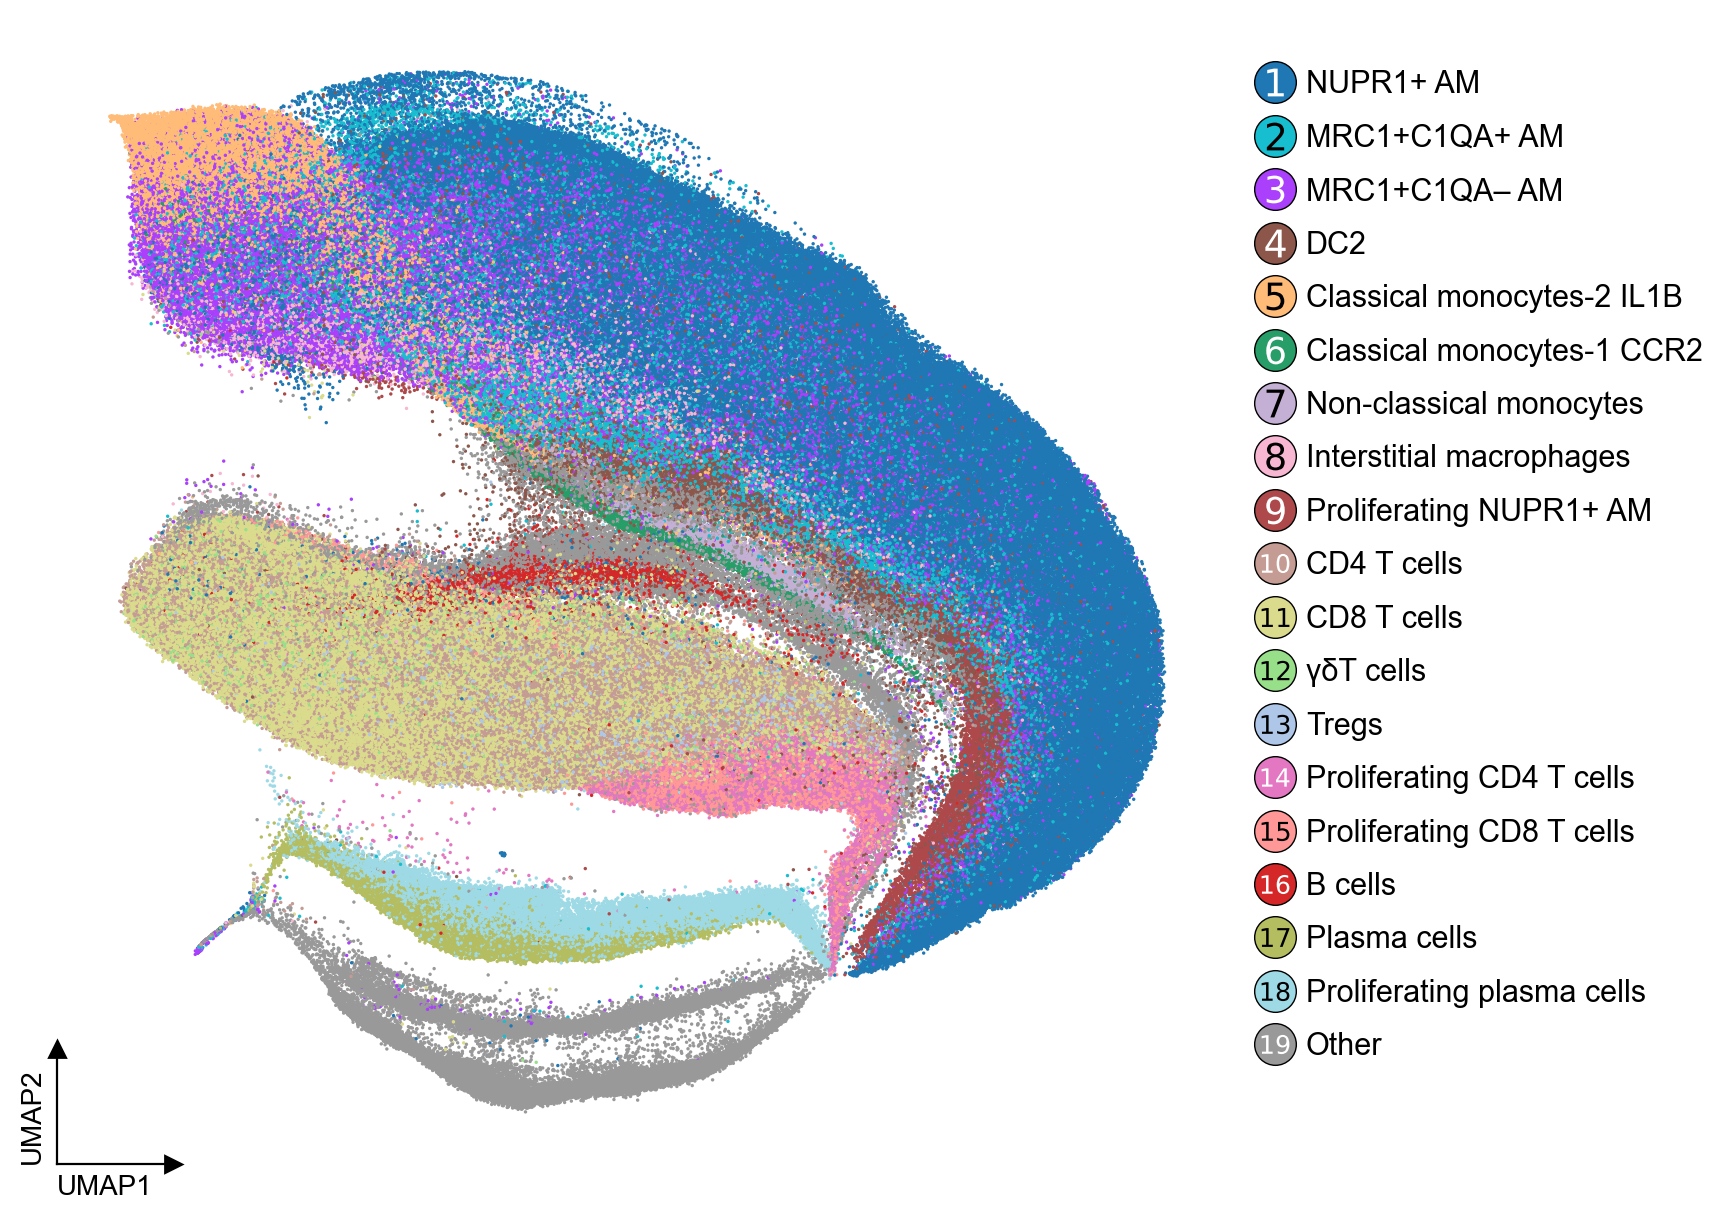

In [15]:
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
sc.pl.umap(
    adata,
    color='cell_type_num',
    legend_loc='none',
    legend_fontweight='normal',
    legend_fontsize=18,
    title='',
    size=6,
    ax=ax,
    show=False
)
shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

width = xlim[1] - xlim[0]
height = ylim[1] - ylim[0]
xbound = xlim[0] + (width) * shrink_by
ybound = ylim[0] + (height) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel(ax.get_xlabel(), x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel(ax.get_ylabel(), y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)

final_labels = []
lh = []
for i, ct in enumerate(adata.obs.cell_type_display.cat.categories):
    lum = sns.utils.relative_luminance(adata.uns['cell_type_num_colors'][i])
    text_color = 'black' if lum > .408 else 'white'
    lh.append((
        mpl.lines.Line2D(
            [0], [0],
            label=ct,
            marker='.',
            markerfacecolor=adata.uns['cell_type_num_colors'][i],
            markeredgecolor='k',
            markersize=30,
            lw=0,
            markeredgewidth=0.5
        ),
        mpl.lines.Line2D(
            [0], [0], label=ct, marker=f'${i + 1}$', markerfacecolor=text_color, markeredgecolor='none',
            markersize=10, lw=0
        ),
    ))
    final_labels.append(ct)

ax.legend(
    handles=lh,
    labels=final_labels,
    fontsize=11,
    loc='upper left',
    bbox_to_anchor=(1, 0.98),
    ncol=1,
    frameon=False,
    labelspacing=0.8,
    handletextpad=0,
    handler_map={tuple: mpl.legend_handler.HandlerTuple()}
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.collections[0].set_rasterized(True)
ax.set_aspect('equal')
# Manual adjustment
fig.canvas.draw()
fig.set_layout_engine("none")
p = ax.get_position()
p.x0 = 0.02
ax.set_position(p)
fig.savefig('00_plots/07b_embeddings_cell_type.pdf', dpi=300)

In [16]:
list(adata.obs.condition.unique())

['Late SARS-CoV-2; Gram+',
 'Early SARS-CoV-2',
 'Gram-*; Gram+',
 'Pseudomonas aeruginosa',
 'Early SARS-CoV-2; Gram+',
 'Late SARS-CoV-2',
 'NPC',
 'Pseudomonas aeruginosa; SARS-CoV-2',
 'Gram-*',
 'Gram+',
 'Healthy',
 'discard']

In [17]:
def add_condition_flags(adata):
    condition_flags = {
        'is_only_virus': ['Early SARS-CoV-2', 'Late SARS-CoV-2'],
        'is_only_bacteria': ['Gram+', 'Gram-*', 'Gram-*; Gram+', 'Pseudomonas aeruginosa'],
        'is_coinfection': ['Late SARS-CoV-2; Gram+', 'Early SARS-CoV-2; Gram+', 'Pseudomonas aeruginosa; SARS-CoV-2'],
        'is_healthy': ['Healthy'],
        'is_npc': ['NPC'],
        'is_late_sars': ['Late SARS-CoV-2'],
        'is_early_sars': ['Early SARS-CoV-2'],
    }

    for flag, conditions in condition_flags.items():
        adata.obs[flag] = adata.obs['condition'].isin(conditions).astype(float)

    long_covid_flag = 'is_long_covid'
    long_covid_cohort_labels = ['LongCOVID']

    adata.obs[long_covid_flag] = adata.obs['cohort'].isin(long_covid_cohort_labels).astype(float)

    return adata

In [18]:
def plot_umap_hexbin(ax, adata, C, title, cmap='flare', cbar=False):
    hb = ax.hexbin(
        x=adata.obsm['X_umap'][:, 0],
        y=adata.obsm['X_umap'][:, 1],
        C=C,
        gridsize=80,
        cmap=cmap,
        # ec='none',
        linewidths=0.05
    )

    shrink_by = 0.1
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
    ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

    ax.spines["bottom"].set_bounds(xlim[0], xbound)
    ax.set_xlabel('UMAP1', x=0, ha="left")
    ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.spines["left"].set_bounds(ylim[0], ybound)
    ax.set_ylabel('UMAP2', y=0, ha="left")
    ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

    norm = plt.Normalize(0, 1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    # Position colorbar at bottom right of each subplot
    if cbar:
        cax = ax.inset_axes([0.6, -0.05, 0.35, 0.02])  # Relative to the axis

        ax.figure.colorbar(
            sm,
            cax=cax,
            label=f'Proportion of cells',
            orientation='horizontal',
            ticks=[0, 0.5, 1]
        )

    ax.set_title(title)
    ax.set_aspect('equal')
    hb.set_rasterized(True)


### Visualization of all of the cell types

In [19]:
adata = add_condition_flags(adata)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


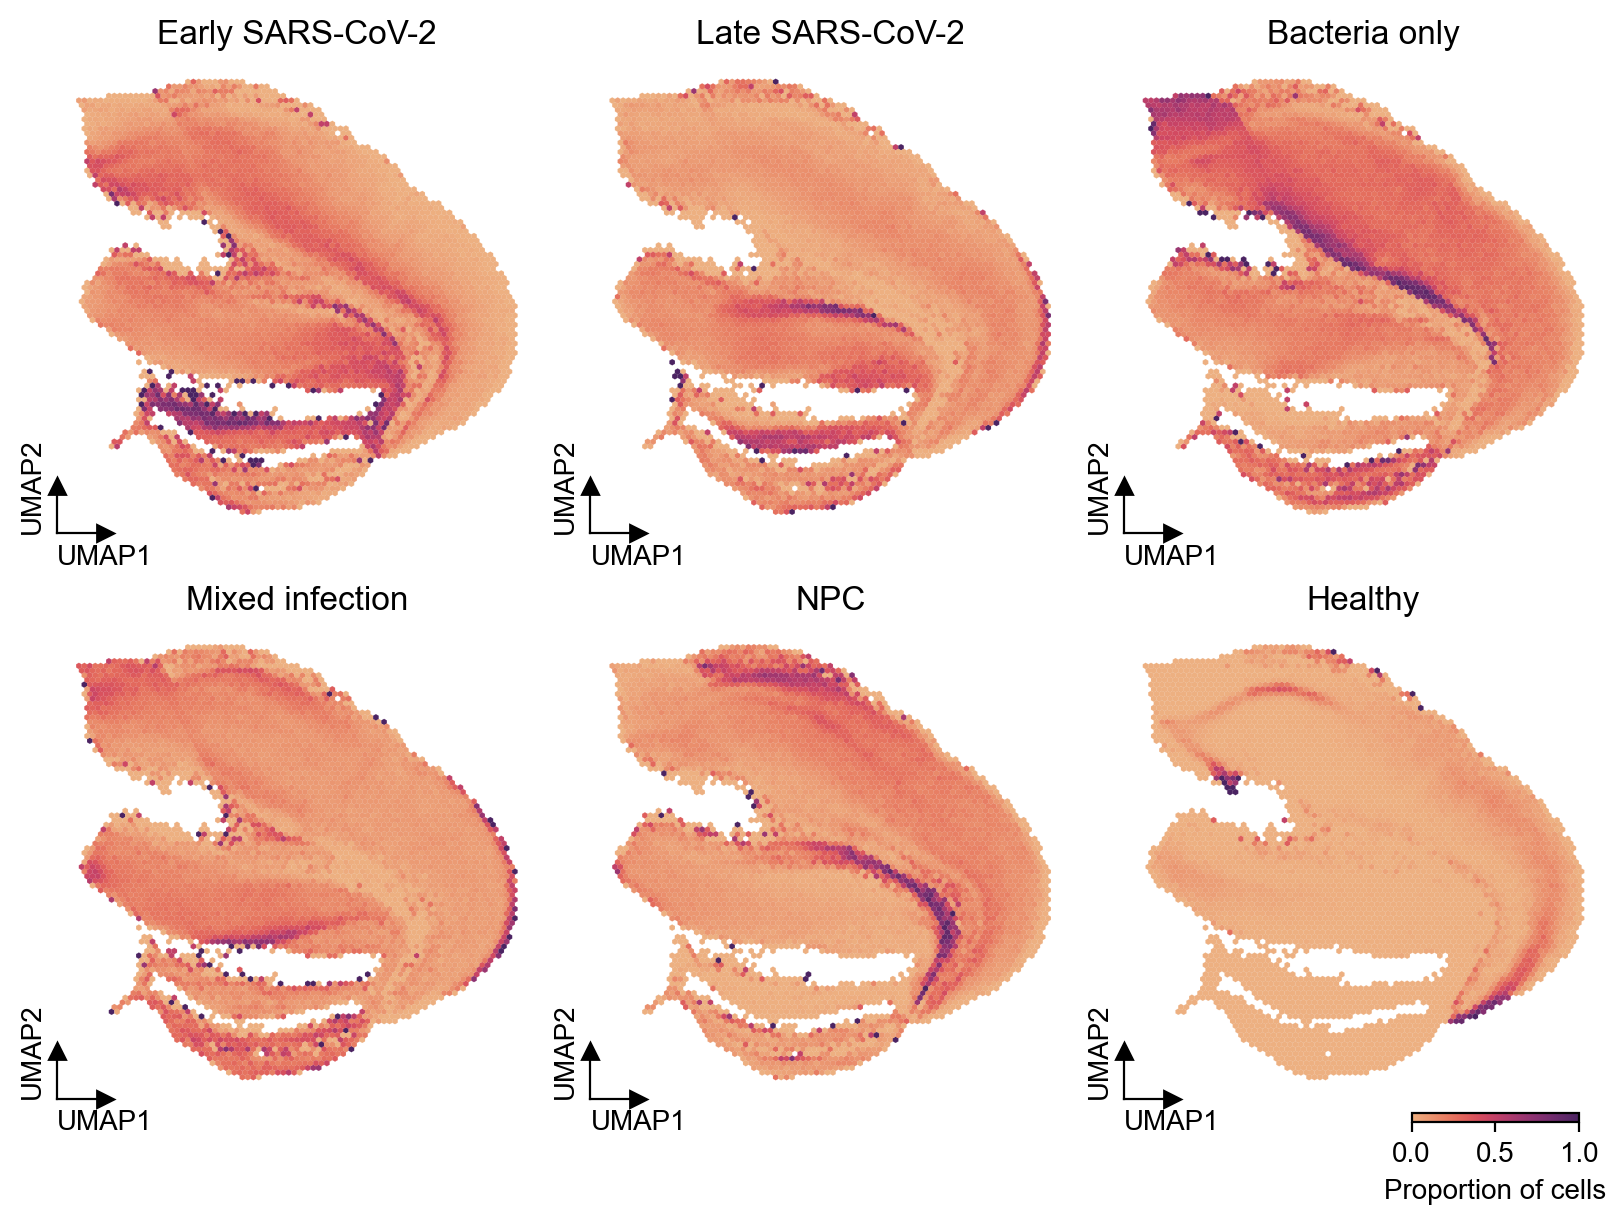

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(8, 6), constrained_layout=True)

plots = [
    ('is_early_sars', 'Early SARS-CoV-2', (0, 0)),
    ('is_late_sars', 'Late SARS-CoV-2', (0, 1)),
    ('is_only_bacteria', 'Bacteria only', (0, 2)),
    ('is_healthy', 'Healthy', (1, 2)),
    ('is_npc', 'NPC', (1, 1)),
    ('is_coinfection', 'Mixed infection', (1, 0)),
]

for key, title, (i, j) in plots:
    cbar = False
    if key == 'is_healthy':
        cbar = True
    plot_umap_hexbin(axes[i, j], adata, adata.obs[key], title, cbar=cbar)

fig.savefig('00_plots/07b_embedding_pathogens.pdf', dpi=450)